# UPI Fraud Detection - Feature Engineering

In the EDA notebook, we found a few patterns that separate fraud from legitimate transactions — things like high amounts, late-night activity, and cross-bank transfers. But right now, those are just *observations*. A machine learning model can't read our conclusions — it can only learn from columns in a table.

So in this notebook, we're going to turn each finding into an actual column. By the end, we'll have a dataset that's ready to feed into a model in the next notebook.

Here's the plan, in order:
1. Load the data
2. Build a feature for high-value transactions
3. Fix the skew in transaction amounts (and explain why that matters)
4. Build a "how unusual is this amount" score
5. Build a feature for round-number amounts
6. Build time-of-day risk features
7. Build a same-bank vs cross-bank feature
8. Put it all together and save the final dataset


---

## 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

COLOR_LEGIT = '#2E86AB'
COLOR_FRAUD = '#E63946'

print("Ready to go!")

Ready to go!


In [2]:
df = pd.read_csv('../data/upi_transactions_2024.csv')

df.rename(columns={
    'transaction id'  : 'transaction_id',
    'transaction type': 'transaction_type',
    'amount (INR)'    : 'amount_inr',
    'timestamp'       : 'txn_timestamp'
}, inplace=True)

df['txn_timestamp'] = pd.to_datetime(df['txn_timestamp'])

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head(3)

Loaded 250,000 rows and 17 columns.


,transaction_id,txn_timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0


## 2: High-Value Transaction Flag

This was the clearest pattern we found in the EDA — transactions above ₹10,000 had a fraud rate of 0.33%, almost double the overall average of 0.19%. That's too useful to leave as just an observation, so let's turn it into a column called `is_high_amount`.

A model can't tell on its own that ₹10,000 is a meaningful cutoff — by creating this column ourselves, we're handing the model a clue we already know matters.

In [3]:
df['is_high_amount'] = (df['amount_inr'] > 10000).astype(int)

# Quick sanity check — does the new column actually capture what we expect?
check = df.groupby('is_high_amount')['fraud_flag'].agg(transactions='count', fraud_rate='mean')
check['fraud_rate'] = (check['fraud_rate'] * 100).round(3)
check.index = ['Normal (≤ ₹10,000)', 'High Value (> ₹10,000)']
check

,transactions,fraud_rate
"Normal (≤ ₹10,000)",248195,0.191
"High Value (> ₹10,000)",1805,0.332


well its good, the numbers match what i saw in the EDA. This column is doing its job.

## 3: Fixing the Skew in Amounts

Here's a problem with `amount_inr` as it stands: most transactions are small (a few hundred rupees), but a handful go up to ₹42,000. That creates a "long tail" — statisticians call this **skewed data**. Some machine learning models (especially simpler ones like Logistic Regression) assume features are roughly evenly spread out, and a heavily skewed column can throw off their results.

Let's actually look at the shape of the data before deciding what to do about it.

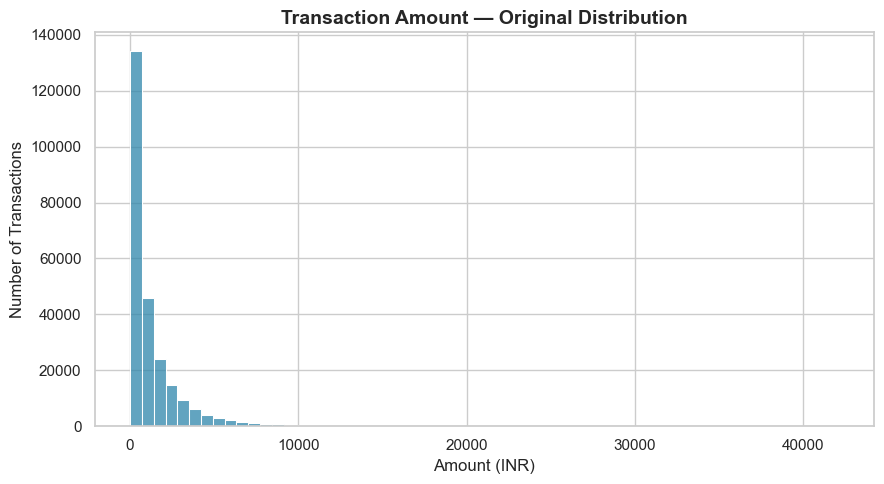

Skewness score: 3.92  (0 = perfectly balanced, higher = more skewed)


In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(df['amount_inr'], bins=60, color=COLOR_LEGIT)
plt.title('Transaction Amount — Original Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Amount (INR)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print(f"Skewness score: {df['amount_inr'].skew():.2f}  (0 = perfectly balanced, higher = more skewed)")

That's a very skewed shape — a tall spike near zero and a long tail stretching out to ₹42,000. A skewness score around 4 is considered heavily skewed (a perfectly even, bell-shaped distribution would score close to 0).

The standard fix here is a **log transform** — instead of using the raw rupee amount, we use its logarithm. This compresses the long tail without losing any information; we can always reverse it later if needed. Let's apply it and see the difference.

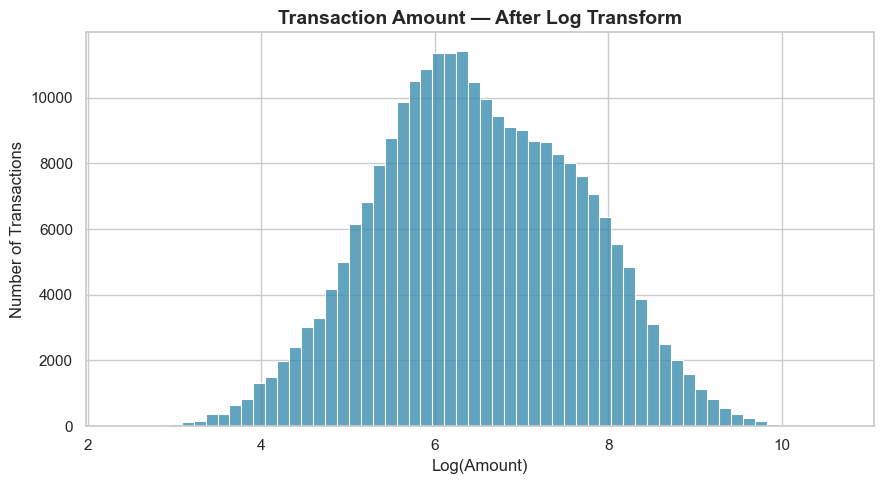

Skewness score after log transform: 0.04


In [5]:
# np.log1p adds 1 before taking the log — this safely handles any amount of ₹0
df['amount_log'] = np.log1p(df['amount_inr'])

plt.figure(figsize=(9, 5))
sns.histplot(df['amount_log'], bins=60, color=COLOR_LEGIT)
plt.title('Transaction Amount — After Log Transform', fontsize=14, fontweight='bold')
plt.xlabel('Log(Amount)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print(f"Skewness score after log transform: {df['amount_log'].skew():.2f}")

Much better — the skewness dropped from ~3.9 to almost 0, and the shape now looks close to a normal bell curve. We'll keep both columns: `amount_inr` (the real rupee value, useful for reporting and dashboards) and `amount_log` (useful as a model input).

---

## 4: How Unusual Is This Amount? (Z-Score)

`is_high_amount` is a simple yes/no cutoff at ₹10,000. But fraud detection systems often want something more precise: *how far is this transaction from what's "normal"?* That's what a **z-score** gives us.

In plain terms, a z-score answers: "how many standard deviations away from the average is this value?" A z-score of 0 means exactly average. A z-score of 3 means this transaction is unusually large compared to most others. It's the same idea your bank uses when it flags a card swipe that's way bigger than your usual spending.

**An important note before we build this:** to calculate a z-score, we need the average and spread (standard deviation) of all transaction amounts. If we calculate that using the *entire* dataset now, and later split the data into "training" and "test" sets for the model, we'd technically be letting information from the test set leak into our training process. For this notebook, we'll calculate it on the full dataset just so we can explore and visualize it — but in the modeling notebook, we'll recalculate it properly using *only* the training data. This is a small but important detail.

In [6]:
mean_amount = df['amount_inr'].mean()
std_amount = df['amount_inr'].std()

df['amount_zscore'] = (df['amount_inr'] - mean_amount) / std_amount

print(f"Average transaction amount : Rs {mean_amount:,.0f}")
print(f"Standard deviation         : Rs {std_amount:,.0f}")
print()
print(df[['amount_inr', 'amount_zscore']].head())

Average transaction amount : Rs 1,312
Standard deviation         : Rs 1,848

   amount_inr  amount_zscore
0         868      -0.240120
1        1011      -0.162742
2         477      -0.451693
3        2784       0.796643
4         990      -0.174105


In [7]:
# Does a more "unusual" amount (far from average) line up with more fraud?
df['is_unusual_amount'] = (df['amount_zscore'].abs() > 2).astype(int)

check = df.groupby('is_unusual_amount')['fraud_flag'].agg(transactions='count', fraud_rate='mean')
check['fraud_rate'] = (check['fraud_rate'] * 100).round(3)
check.index = ['Typical amount', 'Unusual amount (z-score beyond ±2)']
check

,transactions,fraud_rate
Typical amount,239083,0.187
Unusual amount (z-score beyond ±2),10917,0.302


Yes — transactions with an unusually large or small z-score have a higher fraud rate (0.30%) than typical ones (0.19%). This overlaps a bit with `is_high_amount`, but it captures the idea slightly differently (relative to the average, rather than a fixed ₹10,000 cutoff), so we'll keep both and let the model decide which one it finds more useful.

---

## 5: Round-Number Amounts

Here's a pattern worth checking that we didn't cover in the EDA notebook: do fraudsters tend to move "round" amounts — like exactly ₹500 or ₹2,000 — more often than everyday, specific amounts like ₹487 or ₹1,923?

This actually comes from a real fraud-detection concept: automated or scripted fraud (where someone runs a program to move money quickly) tends to use clean, round numbers, while genuine human purchases usually land on odd, specific amounts because they're paying for something with a particular price.

In [8]:
df['is_round_amount'] = (df['amount_inr'] % 100 == 0).astype(int)

check = df.groupby('is_round_amount')['fraud_flag'].agg(transactions='count', fraud_rate='mean')
check['fraud_rate'] = (check['fraud_rate'] * 100).round(3)
check.index = ['Not a round number', 'Round number (multiple of ₹100)']
check

,transactions,fraud_rate
Not a round number,247475,0.191
Round number (multiple of ₹100),2525,0.317


That's a real signal — round-numbered transactions have a fraud rate of 0.32%, compared to 0.19% for everyday amounts. It's a small slice of the data (only about 1% of transactions are round numbers), but it lines up with a known real-world fraud pattern, so it's worth keeping as a feature.

---

## 6: Time-of-Day Risk Features

From the EDA, we saw two time-related patterns:
- A broad "night-time" window (10 PM–5 AM) with a slightly higher fraud rate
- A sharper spike specifically around 3 AM

Let's build both as separate features — a broad one and a narrow one — and let the model figure out which one matters more.

In [9]:
# Broad night window: 10 PM to 5 AM
df['is_night'] = df['hour_of_day'].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)

# Narrow late-night window: 1 AM to 3 AM, where we saw the sharpest spike
df['is_late_night'] = df['hour_of_day'].isin([1, 2, 3]).astype(int)

print("is_night fraud rates:")
print(df.groupby('is_night')['fraud_flag'].mean().mul(100).round(3))

print("\nis_late_night fraud rates:")
print(df.groupby('is_late_night')['fraud_flag'].mean().mul(100).round(3))

is_night fraud rates:
is_night
0    0.190
1    0.205
Name: fraud_flag, dtype: float64

is_late_night fraud rates:
is_late_night
0    0.191
1    0.248
Name: fraud_flag, dtype: float64


As expected from the EDA: the narrow `is_late_night` window (1–3 AM) shows a bigger jump in fraud rate (0.25%) than the broader `is_night` window (0.21%). Both are still useful — the model can combine them with other features rather than us having to pick just one.

---

## 7: Same Bank vs Cross Bank

The last finding from our EDA: transfers between two *different* banks had a slightly higher fraud rate than transfers within the *same* bank.

In [10]:
df['is_same_bank'] = (df['sender_bank'] == df['receiver_bank']).astype(int)

check = df.groupby('is_same_bank')['fraud_flag'].agg(transactions='count', fraud_rate='mean')
check['fraud_rate'] = (check['fraud_rate'] * 100).round(3)
check.index = ['Cross-Bank', 'Same-Bank']
check

,transactions,fraud_rate
Cross-Bank,213679,0.195
Same-Bank,36321,0.173


Confirmed — same as what we saw before. Cross-bank transfers run a bit hotter on fraud rate.

---

In [11]:
new_features = [
    'is_high_amount', 'amount_log', 'amount_zscore', 'is_unusual_amount',
    'is_round_amount', 'is_night', 'is_late_night', 'is_same_bank'
]

print("New engineered features:")
for f in new_features:
    print(f"  - {f}")

print(f"\nDataset shape now: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[new_features].head()

New engineered features:
  - is_high_amount
  - amount_log
  - amount_zscore
  - is_unusual_amount
  - is_round_amount
  - is_night
  - is_late_night
  - is_same_bank

Dataset shape now: 250,000 rows x 25 columns


,is_high_amount,amount_log,amount_zscore,is_unusual_amount,is_round_amount,is_night,is_late_night,is_same_bank
0,0,6.767343,-0.240120,0,0,0,0,0
1,0,6.919684,-0.162742,0,0,0,0,0
2,0,6.169611,-0.451693,0,0,0,0,0
3,0,7.932003,0.796643,0,0,0,0,0
4,0,6.898715,-0.174105,0,0,0,0,0


**A quick note on what we *haven't* done yet, on purpose:** columns like `sender_bank`, `merchant_category`, or `sender_state` are still in their original text form (like "HDFC" or "Grocery"). Machine learning models need numbers, not text, so these will eventually need to be **encoded** into numeric form.

We're deliberately leaving that step for the modeling notebook instead of doing it here. The reason is the same data leakage concern we mentioned earlier with the z-score — some encoding methods (like "replace each bank name with its average fraud rate") need to be calculated only on training data, *after* we've split the data into training and test sets. Doing it here, before any split exists, risks introducing the same kind of leakage. So: feature engineering that only looks at one row at a time happens here; anything that needs to look across rows and could leak information happens later, inside the modeling pipeline, the right way.

In [12]:
# Save the engineered dataset for the next notebook (ML modeling)
output_path = '../data/upi_transactions_features.csv'
df.to_csv(output_path, index=False)

print(f"Saved engineered dataset to: {output_path}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved engineered dataset to: ../data/upi_transactions_features.csv
Final shape: 250,000 rows x 25 columns


## Summary — What We Built

| Feature | What it captures |
|---|---|
| `is_high_amount` | Amount above ₹10,000 (our strongest single clue) |
| `amount_log` | The amount, rescaled to fix its skewed shape |
| `amount_zscore` | How far this amount is from the average, in standard deviations |
| `is_unusual_amount` | A simple yes/no flag for an extreme z-score |
| `is_round_amount` | Whether the amount is a clean multiple of ₹100 |
| `is_night` | Whether the transaction happened between 10 PM and 5 AM |
| `is_late_night` | Whether it happened in the sharper 1–3 AM risk window |
| `is_same_bank` | Whether sender and receiver use the same bank |